In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("c:/Users/WELCOME/Downloads/Telco_customer_churn.xlsx")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape

(7043, 33)

In [5]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [7]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn Reason"]=df["Churn Reason"].fillna("No")

In [9]:
total_customers=df["CustomerID"].nunique()
total_customers

7043

In [10]:
churned_customer=(df["Churn Label"]=="Yes").sum()
churned_customer

np.int64(1869)

In [11]:
retained_customer=(df["Churn Label"]=="No").sum()
retained_customer

np.int64(5174)

In [12]:
churn_rate=(churned_customer/total_customers)*100
churn_rate

np.float64(26.536987079369588)

In [13]:
retain_rate=(retained_customer/total_customers)*100
retain_rate

np.float64(73.4630129206304)

In [14]:
avg_mon_crg=df["Monthly Charges"].mean()
avg_mon_crg

np.float64(64.76169246059918)

In [15]:
df.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

In [16]:
summary={
    "Total Customers":total_customers,
    "Churned Customers":churned_customer,
    "Churn Rate":round(churn_rate,2),
    "Retained Customers":retained_customer,
    "Retain Rate":round(retain_rate,2),
    "Average Monthly Charges":round(avg_mon_crg,2)}
summary

{'Total Customers': 7043,
 'Churned Customers': np.int64(1869),
 'Churn Rate': np.float64(26.54),
 'Retained Customers': np.int64(5174),
 'Retain Rate': np.float64(73.46),
 'Average Monthly Charges': np.float64(64.76)}

In [17]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [18]:
contract_churn=pd.crosstab(df["Contract"],df["Churn Label"],normalize="index")*100
contract_churn.round(2)

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


<Axes: xlabel='Contract', ylabel='Yes'>

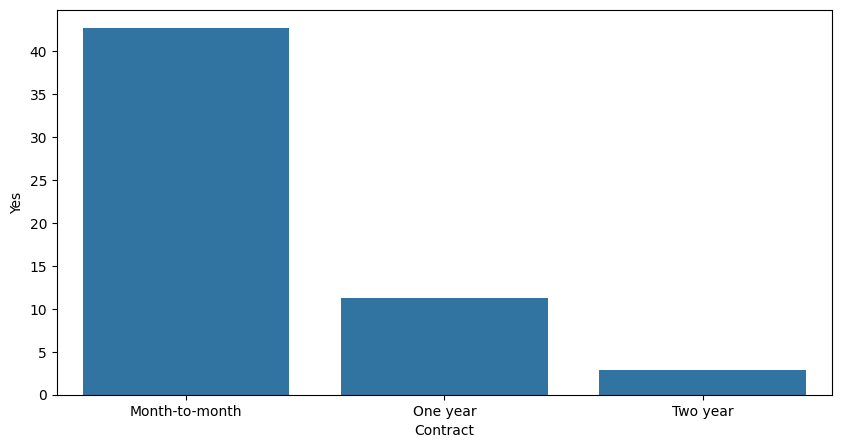

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(x=contract_churn.index,y=contract_churn["Yes"])

In [20]:
df.groupby("Contract")["CustomerID"].nunique()

Contract
Month-to-month    3875
One year          1473
Two year          1695
Name: CustomerID, dtype: int64

In [21]:
df.groupby(["Contract","Churn Label"])["CustomerID"].nunique()

Contract        Churn Label
Month-to-month  No             2220
                Yes            1655
One year        No             1307
                Yes             166
Two year        No             1647
                Yes              48
Name: CustomerID, dtype: int64

In [22]:
df["Tenure Group"]=pd.cut(df["Tenure Months"],bins=[-1,12,24,48,72],labels=["0-12 months","13-24 months","25-48 months","49-72 months"])

In [23]:
df["Tenure Group"].value_counts().sort_index()

Tenure Group
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

In [24]:
tenure_churn=pd.crosstab(df["Tenure Group"],df["Churn Label"],normalize="index")*100
tenure_churn.round(2)

Churn Label,No,Yes
Tenure Group,,
0-12 months,52.56,47.44
13-24 months,71.29,28.71
25-48 months,79.61,20.39
49-72 months,90.49,9.51


<Axes: xlabel='Tenure Group', ylabel='Yes'>

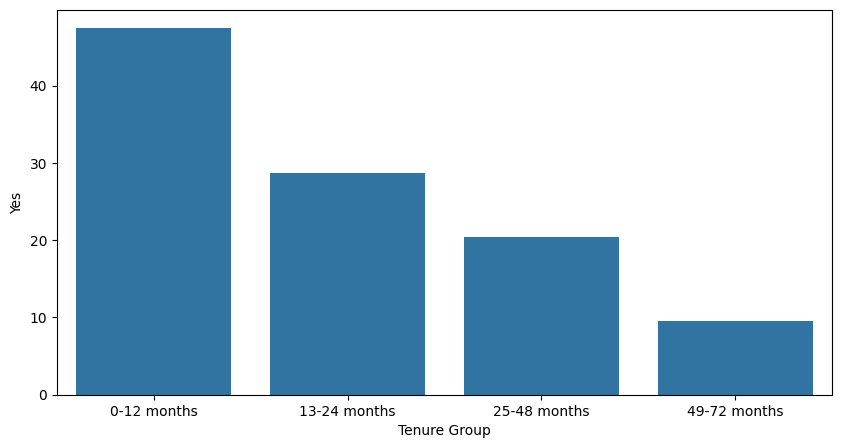

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn["Yes"])

In [26]:
df.groupby("Churn Label")["Monthly Charges"].mean().round(2)

Churn Label
No     61.27
Yes    74.44
Name: Monthly Charges, dtype: float64

In [27]:
df.groupby("Churn Label")["Monthly Charges"].median().round(2)

Churn Label
No     64.43
Yes    79.65
Name: Monthly Charges, dtype: float64

<Axes: xlabel='Churn Label', ylabel='Monthly Charges'>

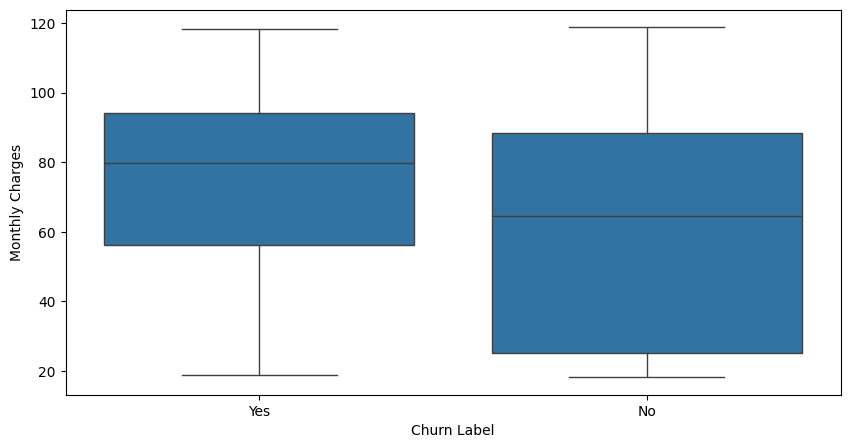

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,
            x="Churn Label",
            y="Monthly Charges")

In [29]:
df["MonthlyChargeGroup"]=pd.cut(df["Monthly Charges"],bins=[0,30,60,90,120],labels=[
    "$0-$30","$31-$60","$61-$90","$91-$120"])

In [30]:
df["MonthlyChargeGroup"].value_counts().sort_index()

MonthlyChargeGroup
$0-$30      1653
$31-$60     1265
$61-$90     2386
$91-$120    1739
Name: count, dtype: int64

In [31]:
charge_churn=pd.crosstab(df["MonthlyChargeGroup"],df["Churn Label"],normalize="index")*100
charge_churn.round(2)

Churn Label,No,Yes
MonthlyChargeGroup,,
$0-$30,90.20,9.80
$31-$60,74.07,25.93
$61-$90,66.09,33.91
$91-$120,67.22,32.78


<Axes: xlabel='MonthlyChargeGroup', ylabel='Yes'>

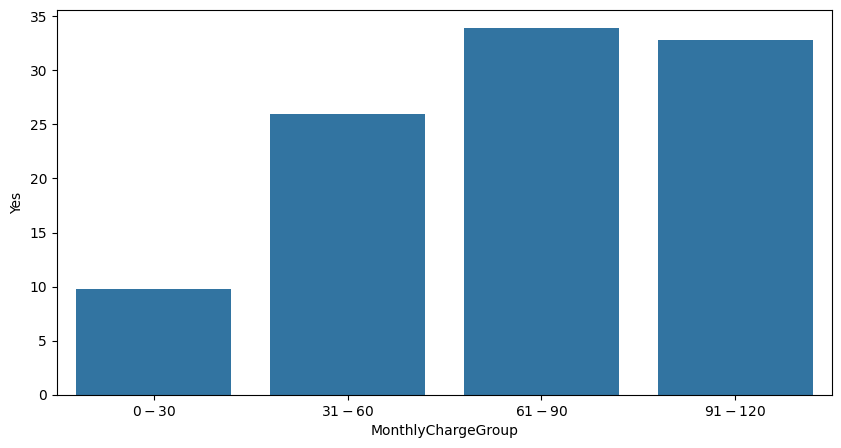

In [32]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=charge_churn.index,
    y=charge_churn["Yes"])

In [33]:
df["Internet Service"].value_counts()

Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [34]:
internet_churn=pd.crosstab(df["Internet Service"],df["Churn Label"],normalize="index")*100
internet_churn.round(2)

Churn Label,No,Yes
Internet Service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


<Axes: xlabel='Internet Service', ylabel='Yes'>

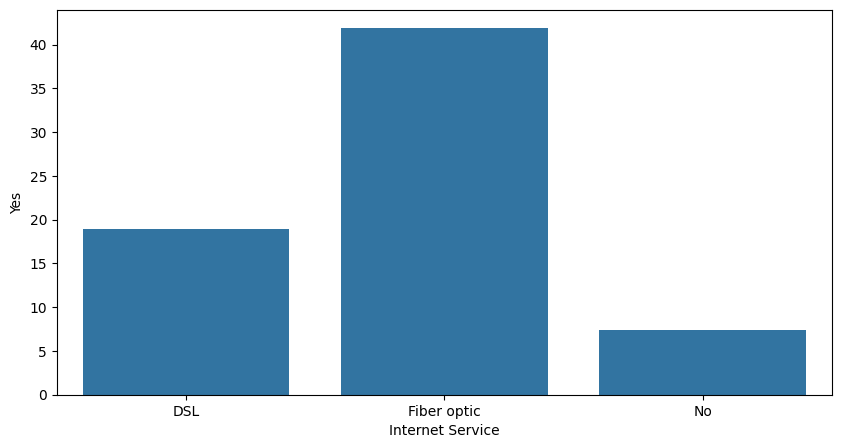

In [35]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=internet_churn.index,
    y=internet_churn["Yes"])

In [36]:
df["Payment Method"].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [37]:
payment_churn=pd.crosstab(df["Payment Method"],
                          df["Churn Label"],
                          normalize="index")*100
payment_churn.round(2)

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


<Axes: xlabel='Payment Method', ylabel='Yes'>

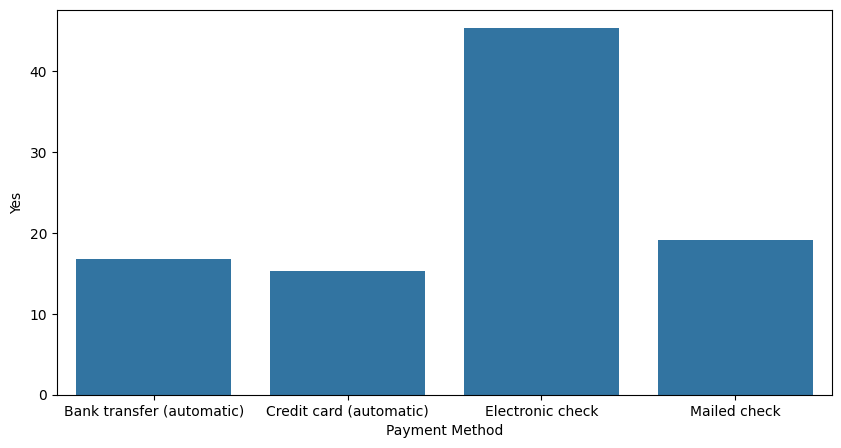

In [38]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=payment_churn.index,
    y=payment_churn["Yes"])

In [39]:
contract_internet=pd.crosstab([df["Contract"],df["Internet Service"]],df["Churn Label"],normalize="index")*100
contract_internet.round(2)

Churn Label                         No    Yes
Contract       Internet Service              
Month-to-month DSL               67.78  32.22
               Fiber optic       45.39  54.61
               No                81.11  18.89
One year       DSL               90.70   9.30
               Fiber optic       80.71  19.29
               No                97.53   2.47
Two year       DSL               98.09   1.91
               Fiber optic       92.77   7.23
               No                99.22   0.78

In [40]:
risk_segment=pd.crosstab([df["Contract"],
                          df["Internet Service"],
                          df["Payment Method"]],
                         df["Churn Label"],normalize="index")*100
risk_segment=risk_segment.round(2)
risk_segment.sort_values("Yes",ascending=False).head(10)

Churn Label                                                   No    Yes
Contract       Internet Service Payment Method                         
Month-to-month Fiber optic      Electronic check           39.63  60.37
                                Mailed check               49.25  50.75
                                Bank transfer (automatic)  54.43  45.57
                                Credit card (automatic)    58.36  41.64
               DSL              Electronic check           59.49  40.51
                                Mailed check               69.21  30.79
                                Credit card (automatic)    72.97  27.03
One year       Fiber optic      Electronic check           73.98  26.02
Month-to-month No               Mailed check               79.38  20.62
                                Bank transfer (automatic)  80.00  20.00

In [41]:
import sqlite3

In [42]:
conn=sqlite3.connect("customer_churn.db")

In [43]:
df.to_sql("customer_churn",conn,if_exists="replace",index=False)

7043

In [44]:
pd.read_sql_query("SELECT * FROM customer_churn LIMIT 5;",conn)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Tenure Group,MonthlyChargeGroup
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,0-12 months,$31-$60
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,0-12 months,$61-$90
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,0-12 months,$91-$120
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,25-48 months,$91-$120
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices,49-72 months,$91-$120


In [51]:
query ="""
SELECT COUNT(*) AS total_customers,
SUM(CASE WHEN "Churn Label"= 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
ROUND(100.0 * SUM(CASE WHEN "Churn Label"= 'Yes' THEN 1 ELSE 0 END)/COUNT(*),2) AS churn_rate
FROM customer_churn;
"""
result=pd.read_sql_query(query,conn)
result

,total_customers,churned_customers,churn_rate
0,7043,1869,26.54


In [52]:
query="""
SELECT Contract,
COUNT(*) AS total_customers,
SUM(CASE WHEN "Churn Label" ='Yes' THEN 1 ELSE 0 END) AS churned_customers,
ROUND(100.0 * SUM(CASE WHEN "Churn Label" ='Yes' THEN 1 ELSE 0 END)/ COUNT(*),2) AS churn_rate
FROM customer_churn
GROUP BY Contract
ORDER BY churn_rate DESC;
"""
contract_sql=pd.read_sql_query(query,conn)
contract_sql

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [56]:
query="""
SELECT CASE
WHEN "Tenure Months" BETWEEN 0 AND 12 THEN '0-12 months'
WHEN "Tenure Months" BETWEEN 13 AND 24 THEN '13-24 months'
WHEN "Tenure Months" BETWEEN 25 AND 48 THEN '25-48 months'
WHEN "Tenure Months" BETWEEN 49 AND 72 THEN '49-72 months'
END AS Tenure_Group,
COUNT(*) AS total_customers,
SUM(CASE WHEN "Churn Label"='Yes' THEN 1 ELSE 0 END) AS churned_customers,
ROUND(100.0*SUM(CASE WHEN "Churn Label"='Yes' THEN 1 ELSE 0 END)/COUNT(*),2) AS churn_rate
FROM customer_churn
GROUP BY Tenure_Group
ORDER BY CASE Tenure_Group
WHEN '0-12 months' THEN 1
WHEN '13-24 months' THEN 2
WHEN '25-48 months' THEN 3
WHEN '49-72 months' THEN 4
END;
"""
tenure_sql=pd.read_sql_query(query, conn)
tenure_sql

,Tenure_Group,total_customers,churned_customers,churn_rate
0,0-12 months,2186,1037,47.44
1,13-24 months,1024,294,28.71
2,25-48 months,1594,325,20.39
3,49-72 months,2239,213,9.51


In [57]:
query="""
WITH churn_summary AS(
SELECT Contract,
"Internet Service", 
COUNT(*) AS total_customers,
SUM(CASE WHEN "Churn Label"='Yes' THEN 1 ELSE 0 END) AS churned_customers
FROM customer_churn
GROUP BY Contract, "Internet Service")
SELECT
Contract, 
"Internet Service",
total_customers,
churned_customers,
ROUND(100.0* churned_customers/total_customers,2) AS churn_rate 
FROM churn_summary
ORDER BY churn_rate DESC;
"""
contract_internet_sql=pd.read_sql_query(query,conn)
contract_internet_sql

,Contract,Internet Service,total_customers,churned_customers,churn_rate
0,Month-to-month,Fiber optic,2128,1162,54.61
1,Month-to-month,DSL,1223,394,32.22
2,One year,Fiber optic,539,104,19.29
3,Month-to-month,No,524,99,18.89
4,One year,DSL,570,53,9.30
5,Two year,Fiber optic,429,31,7.23
6,One year,No,364,9,2.47
7,Two year,DSL,628,12,1.91
8,Two year,No,638,5,0.78


In [60]:
query="""
WITH segment_summary AS(
SELECT 
Contract,
"Internet Service",
"Payment Method",
COUNT(*) AS total_customers,
SUM(CASE WHEN "Churn Label"='Yes' THEN 1 ELSE 0 END) AS churned_customers
FROM customer_churn
GROUP BY
Contract,
"Internet Service",
"Payment Method"),
segment_rates AS (
SELECT 
Contract,
"Internet Service",
"Payment Method",
total_customers,
churned_customers,
ROUND(100.0*churned_customers/total_customers,2) AS churn_rate
FROM segment_summary
WHERE total_customers >=100)
SELECT
Contract,
"Internet Service",
"Payment Method",
total_customers,
churned_customers,
churn_rate,
RANK() OVER(
ORDER BY churn_rate DESC) AS risk_rank
FROM segment_rates
ORDER BY risk_rank;
"""
risk_ranked=pd.read_sql_query(query,conn)
risk_ranked.head(10)

,Contract,Internet Service,Payment Method,total_customers,churned_customers,churn_rate,risk_rank
0,Month-to-month,Fiber optic,Electronic check,1307,789,60.37,1
1,Month-to-month,Fiber optic,Mailed check,201,102,50.75,2
2,Month-to-month,Fiber optic,Bank transfer (automatic),327,149,45.57,3
3,Month-to-month,Fiber optic,Credit card (automatic),293,122,41.64,4
4,Month-to-month,DSL,Electronic check,474,192,40.51,5
5,Month-to-month,DSL,Mailed check,367,113,30.79,6
6,Month-to-month,DSL,Credit card (automatic),185,50,27.03,7
7,One year,Fiber optic,Electronic check,196,51,26.02,8
8,Month-to-month,No,Mailed check,325,67,20.62,9
9,Month-to-month,DSL,Bank transfer (automatic),197,39,19.80,10


In [72]:
sql_file=open("churn_analsis.sql","w")
sql_file.write("""
-- Customer Churn Analysis
-- SQL Portfolio Project


-- 1. Overall Churn
SELECT COUNT(*) AS total_customers,
SUM(CASE WHEN "Churn Label" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
ROUND(100.0 * SUM(CASE WHEN "Churn Label"= 'Yes' THEN 1 ELSE 0 END)/COUNT(*),2) AS churn_rate
FROM customer_churn;


-- 2. Churn By Contract
SELECT Contract,
COUNT(*) AS total_customers,
SUM(CASE WHEN "Churn Label" ='Yes' THEN 1 ELSE 0 END) AS churned_customers,
ROUND(100.0 * SUM(CASE WHEN "Churn Label" ='Yes' THEN 1 ELSE 0 END)/ COUNT(*),2) AS churn_rate
FROM customer_churn
GROUP BY Contract
ORDER BY churn_rate DESC;


-- 3. Churn By Tenure
SELECT CASE
WHEN "Tenure Months" BETWEEN 0 AND 12 THEN '0-12 months'
WHEN "Tenure Months" BETWEEN 13 AND 24 THEN '13-24 months'
WHEN "Tenure Months" BETWEEN 25 AND 48 THEN '25-48 months'
WHEN "Tenure Months" BETWEEN 49 AND 72 THEN '49-72 months'
END AS Tenure_Group,
COUNT(*) AS total_customers,
SUM(CASE WHEN "Churn Label"='Yes' THEN 1 ELSE 0 END) AS churned_customers,
ROUND(100.0*SUM(CASE WHEN "Churn Label"='Yes' THEN 1 ELSE 0 END)/COUNT(*),2) AS churn_rate
FROM customer_churn
GROUP BY Tenure_Group
ORDER BY CASE Tenure_Group
WHEN '0-12 months' THEN 1
WHEN '13-24 months' THEN 2
WHEN '25-48 months' THEN 3
WHEN '49-72 months' THEN 4
END;


-- 4. Churn By Contract+Internet Service 
WITH churn_summary AS(
SELECT Contract,
"Internet Service", 
COUNT(*) AS total_customers,
SUM(CASE WHEN "Churn Label"='Yes' THEN 1 ELSE 0 END) AS churned_customers
FROM customer_churn
GROUP BY Contract, "Internet Service")
SELECT
Contract, 
"Internet Service",
total_customers,
churned_customers,
ROUND(100.0* churned_customers/total_customers,2) AS churn_rate 
FROM churn_summary
ORDER BY churn_rate DESC;


-- 5. Segment By High Risk
WITH segment_summary AS(
SELECT 
Contract,
"Internet Service",
"Payment Method",
COUNT(*) AS total_customers,
SUM(CASE WHEN "Churn Label"='Yes' THEN 1 ELSE 0 END) AS churned_customers
FROM customer_churn
GROUP BY
Contract,
"Internet Service",
"Payment Method"),
segment_rates AS (
SELECT 
Contract,
"Internet Service",
"Payment Method",
total_customers,
churned_customers,
ROUND(100.0*churned_customers/total_customers,2) AS churn_rate
FROM segment_summary
WHERE total_customers >=100)
SELECT
Contract,
"Internet Service",
"Payment Method",
total_customers,
churned_customers,
churn_rate,
RANK() OVER(
ORDER BY churn_rate DESC) AS risk_rank
FROM segment_rates
ORDER BY risk_rank;
""")
sql_file.close()
print("SQL file created successfully")

SQL file created successfully
